**This is a synthetic generated data of quick commerce apps in India having 1000000 rows and 13 columns,we will be trying to analyse which company generates the most rvenue,which type of products people buy more and if there is any correlation between delivery time and review ratings**


**Submitted by Nandhu Krishnan Radhakrishnan**

In [1]:
#Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

import seaborn as sns
import plotly.express as px

In [2]:
# loading Dataset
df = pd.read_csv(r"C:\Users\nandh\quick_commerce_data_raw.csv")

In [3]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [4]:
#checking structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [5]:
# Summary Statistics

df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [6]:
# Checking Missing Values

df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [7]:
# checking the records which contains Any or All null values.

df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


In [8]:
df[df.isna().all(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating


In [9]:
# Droping  rows that have missing values in 'City' column because we cannot use mean or median here

df = df.dropna(subset = ['City'])

In [10]:
#checking if rows are removed
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [11]:
df.shape

(948000, 13)

In [12]:
# Checking Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [13]:
x = df['Items_Count'].mean()

In [14]:
x

np.float64(9.997801638003788)

In [15]:
#filling median to missing values
df = df.copy()
df['Items_Count'] = df['Items_Count'].fillna(x)

In [16]:
# Checkong Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [17]:
# Filling mean for customer rating

df['Customer_Rating'] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))

In [18]:
# Checking Missing Values

df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [19]:
# Filling mean for delivery partner rating
df['Delivery_Partner_Rating'] = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))

In [20]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.000000,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.000000,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,9.997802,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.000000,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.000000,Household,Wallet,3.7,0,4.8


In [21]:
# Checking Missing Values

df.isna().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [22]:
#filling again with mean
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna( df['Delivery_Partner_Rating'].mean() )

In [23]:
# Checking Missing Values

df.isna().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [24]:
# Dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


<Axes: >

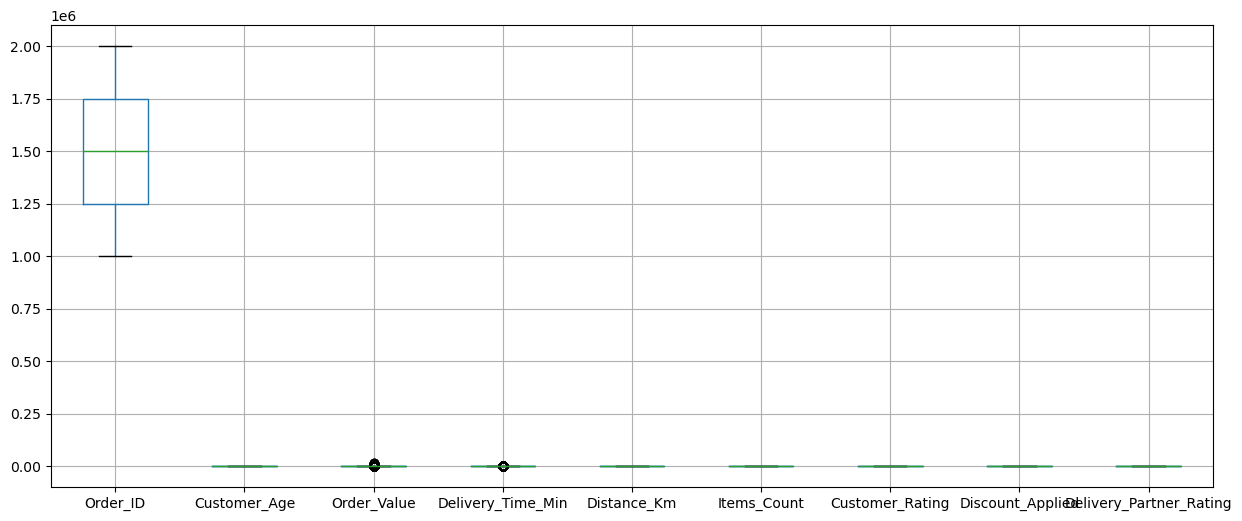

In [25]:
#cheking outliers
# Box Plot

plt.figure(figsize = (15,6))

df.boxplot()

<Axes: >

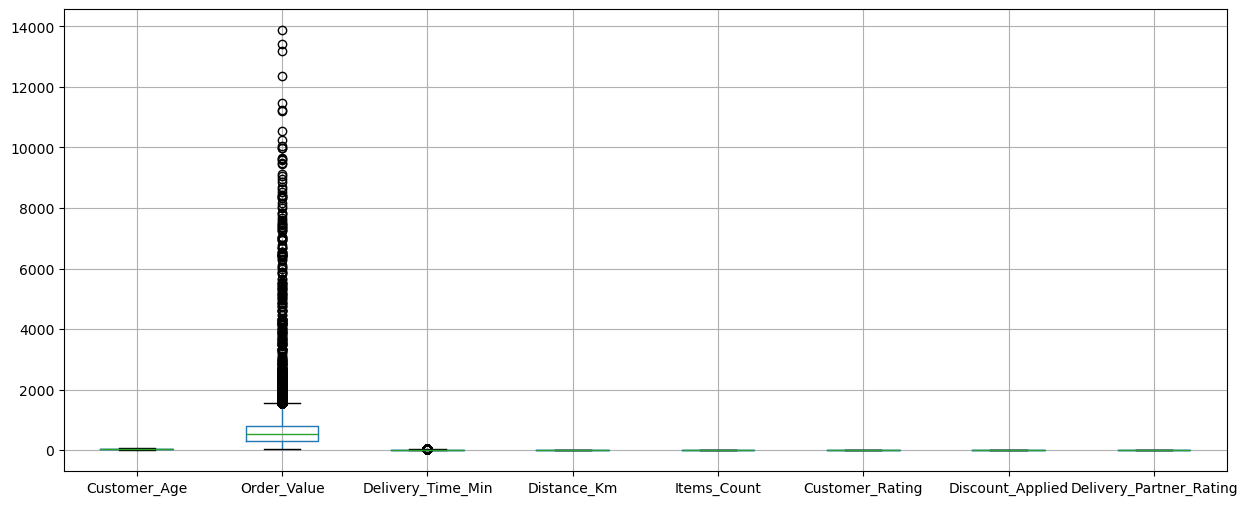

In [26]:
# Box Plot without 'Order ID' column because it has very high values

plt.figure(figsize = (15,6))

df.drop(columns = ['Order_ID']).boxplot()

In [27]:
# using percentile capping to remove outliers in order value any value above 2500 will be now turned to 2500
df['Order_Value'] = df['Order_Value'].clip(upper = 2500)

In [28]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.000000,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.000000,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,9.997802,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.000000,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.000000,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.000000,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.000000,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.000000,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.000000,Snacks,Wallet,4.0,1,4.5


<Axes: >

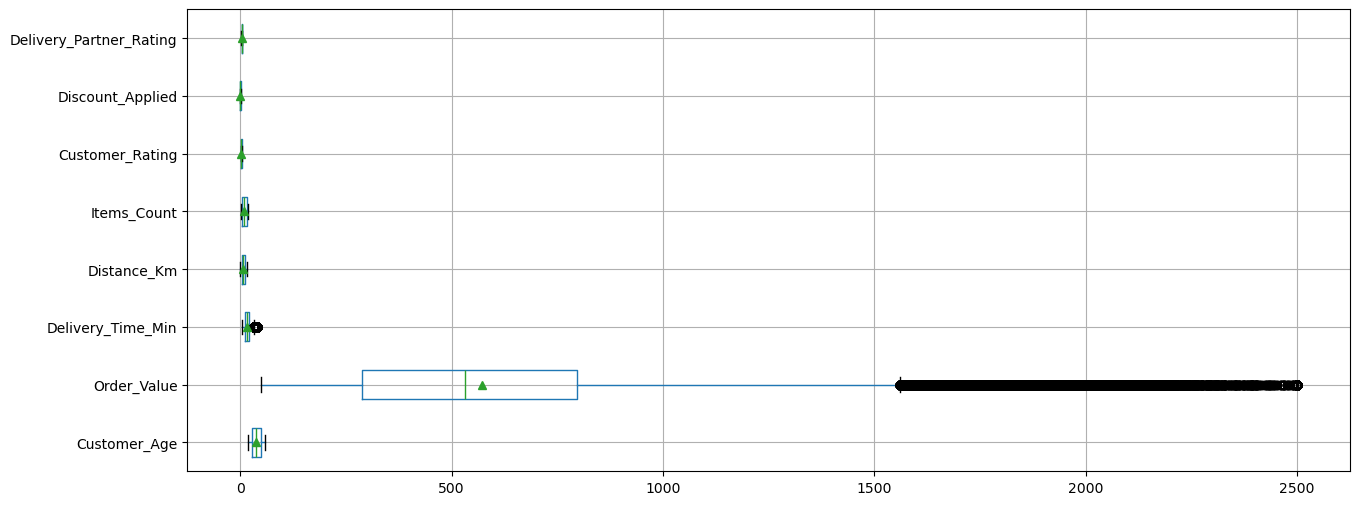

In [29]:
# Box Plot without 'Order ID' column

plt.figure(figsize = (15,6))

df.drop(columns = ['Order_ID']).boxplot(vert = False, showmeans = True)

In [30]:
# Summary Statistics

df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.480000e+05,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000,948000.000000
mean,1.500024e+06,38.471327,571.417040,16.501932,7.750000,9.997802,3.042883,0.400826,3.749178
std,2.887244e+05,12.118978,375.424317,6.330006,4.187026,5.381917,1.161115,0.490066,0.684364
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249946e+06,28.000000,287.992575,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.786950,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750130e+06,49.000000,796.844125,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2500.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [31]:
# Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


In [32]:
#changing column types
# Change data-type of Order ID

df['Order_ID'] =  df['Order_ID'].astype(str)

In [33]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.000000,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.000000,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,9.997802,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.000000,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.000000,Household,Wallet,3.7,0,4.8


In [34]:
# Rounding-off the float values

df['Order_Value'] = np.round(df['Order_Value'])

df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])

df['Distance_Km'] = np.round(df['Distance_Km'], 1)

df['Customer_Rating'] = np.round(df['Customer_Rating'])

df['Delivery_Partner_Rating'] = np.round(df['Delivery_Partner_Rating'])

In [35]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.000000,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.000000,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,9.997802,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.000000,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.000000,Household,Wallet,4.0,0,5.0


In [36]:
# Changing the data-type of float columns to integer

df['Order_Value'] = df['Order_Value'].astype(int)

df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)

df['Items_Count'] = df['Items_Count'].astype(int)

df['Customer_Rating'] = df['Customer_Rating'].astype(int)

df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].astype(int)

In [37]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,9,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72,18,3.0,19,Fruits & Vegetables,Wallet,4,0,3
999996,1999997,Swiggy Instamart,Mumbai,33,1510,18,10.5,9,Beverages,Debit Card,4,1,4
999997,1999998,Jio Mart,Noida,29,637,18,2.6,6,Groceries,Cash on Delivery,3,0,5
999998,1999999,Dunzo,Pune,42,1103,13,7.8,12,Snacks,Wallet,4,1,4


In [38]:
# Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  object 
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  int64  
 5   Delivery_Time_Min        948000 non-null  int64  
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  int64  
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  int64  
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  948000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 101.3+ MB


**BUSINESS QUESTIONS**



**Q1,Which quick commerce platform has the highest total revenue?**


In [39]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,9,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [40]:
# Grouping Data - Calculate total order value for companies

company_revenue = df.groupby('Company')['Order_Value'].sum()

company_revenue

Company
Amazon Now          65892504
Big Basket          67974762
Blinkit             72589575
Dunzo               64070079
Flipkart Minutes    67058289
Jio Mart            57160360
Swiggy Instamart    76532756
Zepto               70424672
Name: Order_Value, dtype: int64

In [41]:
# Sorting Grouped Data

company_revenue.sort_values()

Company
Jio Mart            57160360
Dunzo               64070079
Amazon Now          65892504
Flipkart Minutes    67058289
Big Basket          67974762
Zepto               70424672
Blinkit             72589575
Swiggy Instamart    76532756
Name: Order_Value, dtype: int64

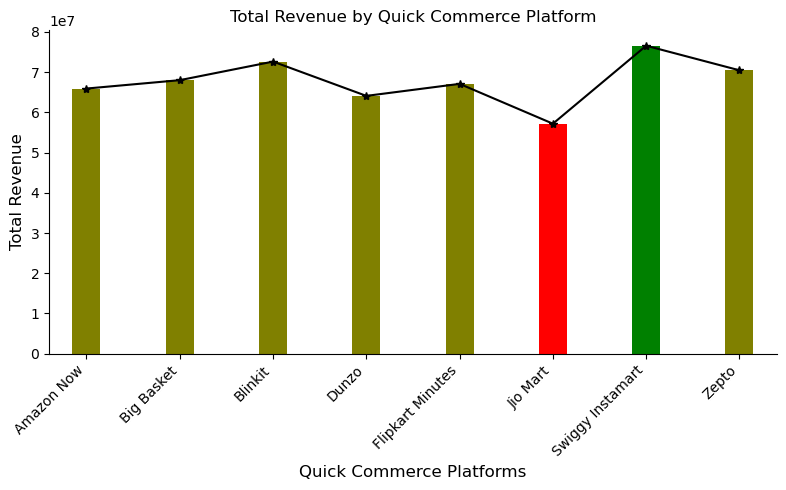

In [42]:
# Bar and Line Chart

plt.figure(figsize = (8,5))

# Find max and min revenue
max_val = company_revenue.max()
min_val = company_revenue.min()

# Assign colors based on value
colors = ['green' if val == max_val else
          'red' if val == min_val else
          'olive'
          for val in company_revenue          
         ]


# Draw Bar & Line Chart at once
company_revenue.plot( kind = 'bar', color = colors, width = 0.3)
company_revenue.plot( kind = 'line', color = 'black', marker = '*')

plt.xlabel("Quick Commerce Platforms", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.title("Total Revenue by Quick Commerce Platform")
plt.xticks(rotation=45, ha="right")

ax = plt.gca()    # gca - get current axis

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

**As we can see here Swiggy instamart generates the most revenue**

**Q.2) Which platform has the highest average order value (AOV)?**

In [43]:
# Calculating average order value for companies

df.groupby('Company')['Order_Value'].mean()

Company
Amazon Now          557.905154
Big Basket          575.652397
Blinkit             610.391388
Dunzo               540.730530
Flipkart Minutes    563.567128
Jio Mart            483.238591
Swiggy Instamart    645.709816
Zepto               593.804939
Name: Order_Value, dtype: float64

In [44]:
AOV =  df.groupby('Company')['Order_Value'].mean().sort_values()

AOV

Company
Jio Mart            483.238591
Dunzo               540.730530
Amazon Now          557.905154
Flipkart Minutes    563.567128
Big Basket          575.652397
Zepto               593.804939
Blinkit             610.391388
Swiggy Instamart    645.709816
Name: Order_Value, dtype: float64

In [45]:
type(AOV)

pandas.core.series.Series

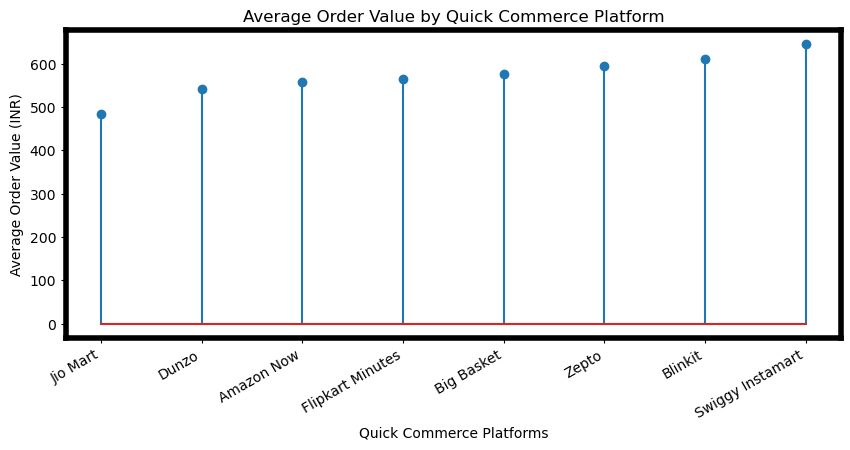

In [46]:
# Stem Chart

plt.figure(figsize = (10,4))

plt.stem(AOV.index, AOV.values)         # stem chart

plt.xlabel("Quick Commerce Platforms")
plt.ylabel("Average Order Value (INR)")
plt.title("Average Order Value by Quick Commerce Platform")
plt.xticks(rotation=30, ha="right")

ax = plt.gca()

# Highlight all four borders
ax.spines['top'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)


plt.show()

**Here also Swiggy instamart has the highest average order value**

**Q.3) How does Customer Rating vary across platforms?**

In [47]:
#  Calculating average rating for companies

df.groupby('Company')['Customer_Rating'].mean().sort_values()

Company
Dunzo               2.428035
Jio Mart            2.819759
Amazon Now          2.913434
Flipkart Minutes    3.016438
Big Basket          3.097940
Zepto               3.202995
Swiggy Instamart    3.279553
Blinkit             3.580703
Name: Customer_Rating, dtype: float64

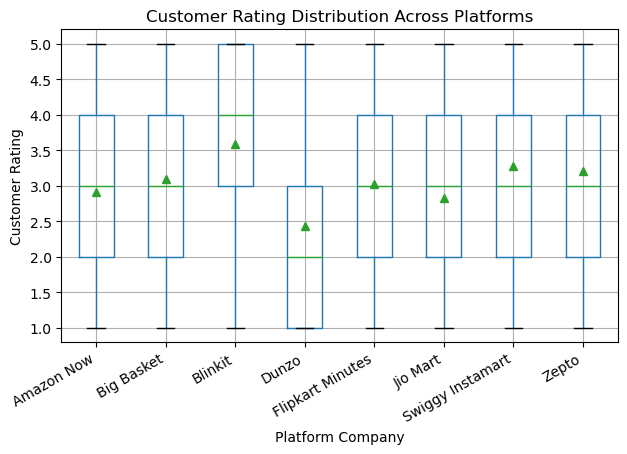

In [48]:
# Box Plot

df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

plt.title("Customer Rating Distribution Across Platforms")

plt.suptitle("") # Remove default pandas title

plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha = 'right')    # ⬅️ Rotating labels for clarity

plt.tight_layout()                  # ⬅️ Auto adjust spacing
plt.show()

In [49]:
# Group Data

grouped_rating =  df.groupby(['Company', 'Customer_Rating']).size().unstack(fill_value=0)

grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15980,30358,30870,29704,11195
Big Basket,10144,30351,31027,30918,15643
Blinkit,1061,25563,25567,36720,30012
Dunzo,29825,36285,25385,25822,1171
Flipkart Minutes,12550,30789,31232,30991,13427
Jio Mart,18516,30519,31088,30095,8068
Swiggy Instamart,5002,30287,31051,30945,21240
Zepto,7619,29773,31380,30568,19259


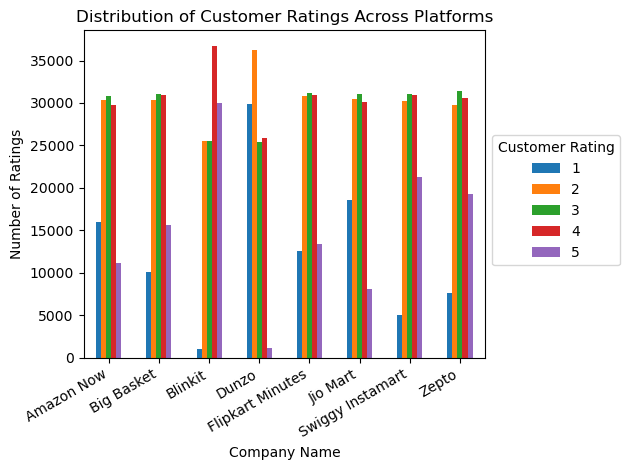

In [50]:
# Bar Chart for Grouped Ratings

grouped_rating.plot(kind = 'bar')

plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Customer Ratings Across Platforms")

plt.legend(title = 'Customer Rating', bbox_to_anchor = (1, 0.7), loc = 'upper left')

plt.xticks(rotation = 30, ha = 'right')

plt.tight_layout()
plt.show()

**Here blinkit has the most 4 star and 5 star reviews making them the best**

**Q.4) Does 'Delivery Time' affects the 'Delivery Partner Ratings'?**

In [51]:
# taking mean of delivery time
df['Delivery_Time_Min'].mean()

np.float64(16.506478902953585)

In [52]:
#taking mean of delivery partner rating
df['Delivery_Partner_Rating'].mean()

np.float64(3.8002943037974686)

In [53]:
# Calculating average rating for delivery timings

x = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()

x

Delivery_Time_Min
5     3.804022
6     3.798591
7     3.805865
8     3.803796
9     3.804402
10    3.801602
11    3.799979
12    3.798861
13    3.795765
14    3.797314
15    3.798016
16    3.799100
17    3.802359
18    3.801807
19    3.809682
20    3.804834
21    3.802936
22    3.804560
23    3.794302
24    3.791276
25    3.800332
26    3.795161
27    3.799749
28    3.796468
29    3.792997
30    3.788623
31    3.807241
32    3.789289
33    3.781402
34    3.770451
35    3.779251
36    3.752239
37    3.732039
38    3.741307
39    3.799097
40    3.737589
Name: Delivery_Partner_Rating, dtype: float64

In [54]:
#checking correlation to find if there is any significant impact
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.0027711759347191444)

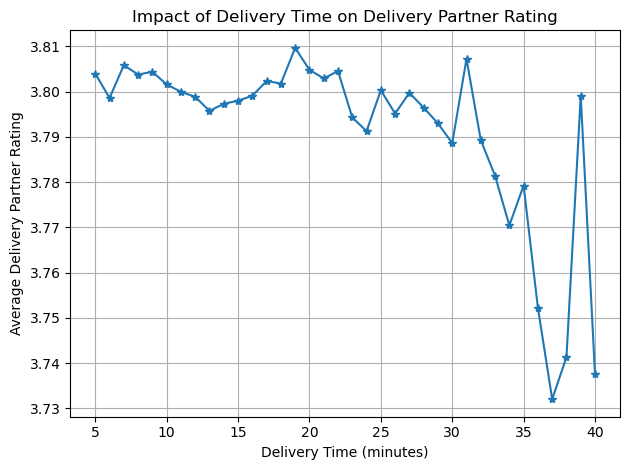

In [55]:
# Line Chart

x.plot(marker = '*')

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)

plt.tight_layout()
plt.show()

**Correlation analysis yielded r = -0.0028 between Delivery Time Min and Delivery Partner Rating (p > 0.05is non-significant). This negligible link is visualized in the stable line plot of binned averages,So there is no great impact on faster delivery,It maybe also due to orders in hightraffic areas the excepted time to deliver maybe 40 and they give good ratings for that)**

**Q.5) What is the most popular Product Category on Swiggy Instamart, for the people of age between 20-30, in Mumbai?**

In [56]:
# filtering

df_pc = df[
           (df['Company'] ==  'Swiggy Instamart') &
           ((df['Customer_Age'] >= 20) & (df['Customer_Age'] < 30)) &
           (df['City'] == 'Mumbai')
           ]

df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
704,1000705,Swiggy Instamart,Mumbai,22,533,19,10.7,16,Fruits & Vegetables,Cash on Delivery,3,0,4
1361,1001362,Swiggy Instamart,Mumbai,29,1096,18,11.9,15,Personal Care,Wallet,4,1,4
1388,1001389,Swiggy Instamart,Mumbai,21,364,19,8.6,2,Groceries,Cash on Delivery,3,1,4
1412,1001413,Swiggy Instamart,Mumbai,20,668,14,5.4,18,Fruits & Vegetables,Wallet,2,1,5
4445,1004446,Swiggy Instamart,Mumbai,21,168,20,12.3,11,Household,Cash on Delivery,4,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
998245,1998246,Swiggy Instamart,Mumbai,20,50,13,2.7,8,Dairy,Wallet,3,0,3
998524,1998525,Swiggy Instamart,Mumbai,21,1320,16,9.1,2,Beverages,Credit Card,2,1,4
998846,1998847,Swiggy Instamart,Mumbai,23,50,17,10.5,19,Household,UPI,4,0,4
999454,1999455,Swiggy Instamart,Mumbai,24,1246,18,7.0,12,Groceries,Credit Card,3,1,4


In [57]:
# Most popular product category

df_pc['Product_Category'].value_counts()

Product_Category
Household              355
Fruits & Vegetables    334
Dairy                  326
Snacks                 321
Groceries              313
Beverages              302
Personal Care          297
Name: count, dtype: int64

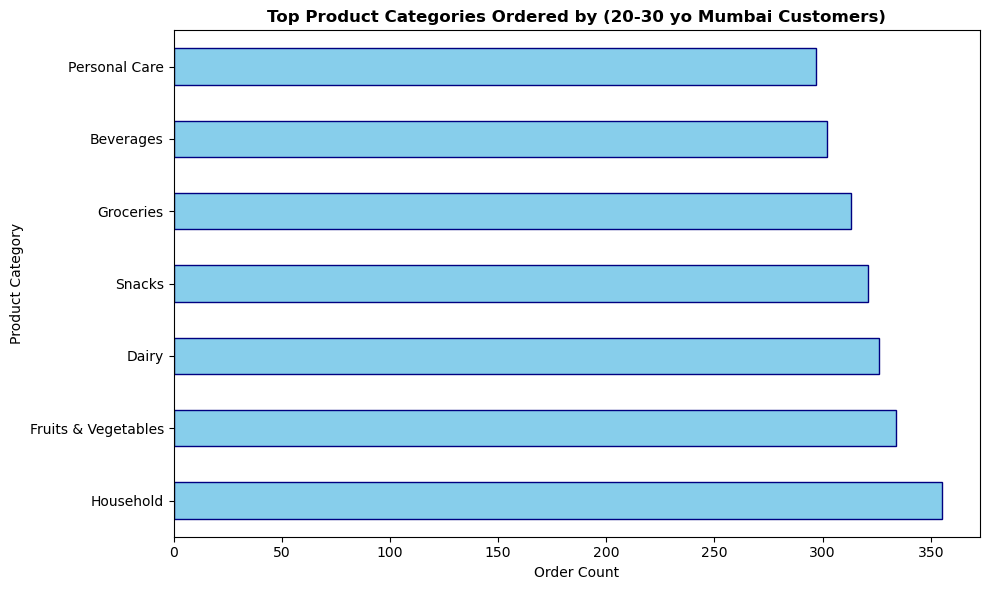

In [58]:
value_counts = df_pc['Product_Category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
value_counts.plot(kind='barh', color='skyblue', edgecolor='navy')
plt.title('Top Product Categories Ordered by (20-30 yo Mumbai Customers)', fontweight='bold')
plt.xlabel('Order Count')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


**As you can see people aged between 20 and 30 in mumbai prefer to order household items**

**Q6,Are discounts increasing order volume or just reducing revenue?¶**

In [59]:
# Counting the number of orders with and without discount

df['Discount_Applied'].value_counts()

Discount_Applied
0    568017
1    379983
Name: count, dtype: int64

In [60]:
#  Calculating average order value

dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()

dis_order_value

Discount_Applied
0    476.812594
1    712.835411
Name: Order_Value, dtype: float64

In [61]:
#  Calculating sum of items count

dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()

dis_items_count

Discount_Applied
0    5655073
1    3789688
Name: Items_Count, dtype: int64

In [62]:
x = df['Discount_Applied'].unique()
print(x)

[1 0]


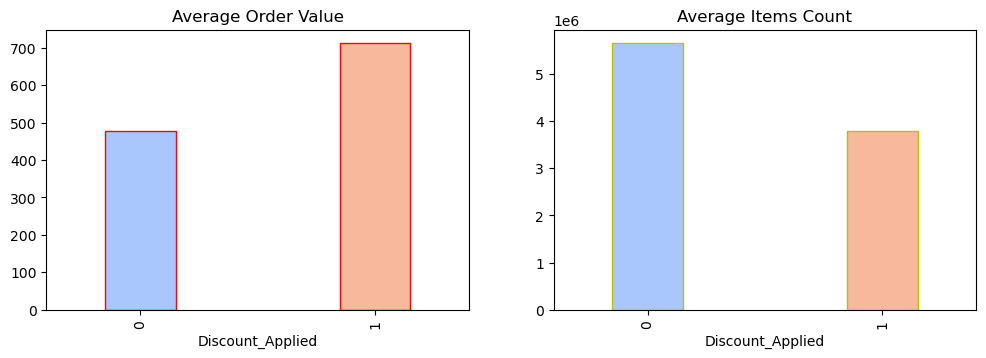

In [63]:
plt.figure(figsize=(12,8))

# use gradient colors
colors = sns.color_palette("coolwarm", len(x))

plt.subplot(2,2,1)
dis_order_value.plot(kind = 'bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Average Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'y', color = colors)
plt.title("Average Items Count")


plt.show()

**As you can see Discounts increase both order volume (items count ~5x higher) and revenue (AOV ~2x higher), providing net positive impact rather than just reducing revenue.**

**AI Usage - I used Ai for interpreting the results and generating syntax for removing outliers and cleaning data**